# **Classification** **Notebook**

In [41]:
# Import files module from Google Colab
# This is used to upload files from your local system to Colab
from google.colab import files

# Opens file upload dialog to upload zip file
files.upload()

Saving archive.zip to archive (2).zip


{'archive (2).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00\x15B\xd5RL\xd9\xa0\xba\xff\xff\xff\xff\xff\xff\xff\xff\x08\x00\x14\x00spam.csv\x01\x00\x10\x00\x82S\x07\x00\x00\x00\x00\x006=\x03\x00\x00\x00\x00\x00\xd4\xbd\xcbr\x1b[\x92%:\xef\xaf\xd8d\xb5\x1d\xa5N\x82\x10\x00\x82\xcf\xb2*&HB"$\x92\xe0!@Q\xaa\xc9\xb5\x00\x10\x00BDD \xe3A\x10\xb2\xb6\xb6\xfa\x86\xbe\x93\x1a\xd4,\xff\xe2Z\x8e2\xff\xa4\xbe\xe4\xfaZ\xee;\x00\xead\xa6uv\xd7\xa0[yR"\x81x\xee\x87?\x96/w\xbf\x08\x8ap\x96f\xeb\xdaM\x98\xe7\xc1,\xfc/\xf3 \xae\xed~H]\x99\x14\xd1\xc2}+\xb34\x99\xb9e\x1a%E\xcd\x8d\xb3\xe0\xfb\xba^w\x9d\xe7 Z\x04\xa3E\xe8\xd2d\xb1vQ\xe2F\xe5,\xca]\xe2fY\x18\x14n\x95f\x8b\x89[\x04.\x94/\xa6\xd3\xb0\xa8\xcbI\x17Q\x12\xbab\x1ef\xa1\x9b\xa5\x85\x0b\xe2T~Z\x05\xf8n\x97w\xed?\xc9)\x19\x0e\xfd\x98>Er\xd7U4u\xa5\xdc"\x92\xcf\xfeK\xbe\x94C\xdega\xe8\xc2\xa4\xc8x\xd3\x96\x0b\xdc\xeaI\x1e`\x9c\xc6KW\xa4rB\xe2\xdew\xdcE\xb9t\xd3(\t\x16\xaex*r\xd7j\xe6\x85\xbb\t\xd6\xae\xd5h\x1c\xd4\xdd0|)p\x94\x1c\x7f|\xd4l5\xf1C\x16\x8e\x

In [42]:
# Import zipfile module to work with zip files
import zipfile

# Open the zip file in read mode
# Extract all contents of 'students_marks.zip' into current directory
with zipfile.ZipFile('archive.zip','r') as zip_ref:
  zip_ref.extractall()

In [43]:
# Import os module to interact with operating system
import os

# List all files and folders in the current directory
# Used to verify whether CSV file is extracted correctly
os.listdir()

['.config',
 'spam_classification_model.pkl',
 'spam_vectorizer.pkl',
 'archive (1).zip',
 'spam.csv',
 'archive (2).zip',
 'archive.zip',
 'spam.csv.xlsx',
 'sample_data']

**Load** **the** **Dataset**

The dataset is loaded from a CSV file into a DataFrame.

Encoding is specified to avoid text decoding errors.

In [44]:
# Import pandas for data manipulation
import pandas as pd

# Load spam dataset with proper encoding
df = pd.read_csv('spam.csv', encoding='latin-1')
# Select only required columns
df = df[['Category', 'Message']]

**Exploratory** **Data** **Analysis** (**EDA**)

EDA helps to understand dataset structure and class distribution.

It identifies imbalance and verifies data correctness.

In [45]:
# Display first 5 rows of the dataset
df.head()
# Check count of spam and ham messages
df['Category'].value_counts()

,count
Category,
ham,4825
spam,747


**Data** **Cleaning**

This step ensures there are no missing or invalid values.

Clean data improves model performance.

In [46]:
# Check for missing values
df.isnull().sum()

,0
Category,0
Message,0


**Encoding** **Target** **Variable**

Machine learning models cannot understand text labels.

So, categorical values are converted into numerical values.

In [47]:
# Convert categorical labels into numerical form
# ham -> 0, spam -> 1
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

**Feature** **Extraction** (**Text** **to** **Numerical**)

Text data must be converted into numerical vectors.

CountVectorizer converts text into word frequency vectors.

In [48]:
# Import CountVectorizer for text feature extraction
from sklearn.feature_extraction.text import CountVectorizer

# Initialize vectorizer
vectorizer = CountVectorizer()

# Convert message text into numerical feature matrix
X = vectorizer.fit_transform(df['Message'])

# Define target variable
y = df['Category']

**Train–Test** **Split**

The dataset is split into training and testing parts.

This helps evaluate model performance on unseen data.

In [49]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

**Model** **Training** (**Classification** **Algorithm**)

Naive Bayes is suitable for text classification problems.

The model learns patterns from training data.

In [50]:
# Import Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Initialize the model
model = MultinomialNB()

# Train the model using training data
model.fit(X_train, y_train)

MultinomialNB()

**Prediction**

The trained model predicts labels for test data.

Predictions are compared with actual labels.

In [51]:
# Predict spam or ham for test data
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9856502242152466


In [53]:
# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Print classification performance report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



**Confusion** **Matrix** & **Heatmap**

Confusion matrix shows correct and incorrect predictions.

Heatmap visualizes model performance clearly.

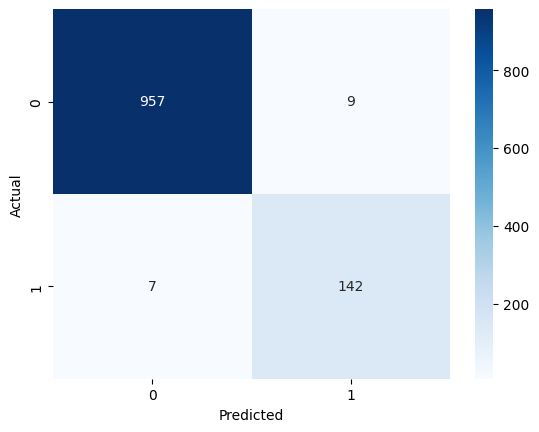

In [54]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix
# Import visualization libraries

import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap for confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Label axes
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Display the plot
plt.show()

# **Inference**

In [55]:
import joblib

# Save trained regression model
joblib.dump(model, "spam_classification_model.pk")

# Save scaler
joblib.dump(vectorizer, "spam_vectorizer.pkl")


['spam_vectorizer.pkl']

In [56]:
# Import joblib to load saved model and vectorizer
import joblib

# Load the trained classification model (Naive Bayes / Logistic Regression)
loaded_model = joblib.load("/content/spam_classification_model.pkl")

# Load the saved text vectorizer used during training
loaded_vectorizer = joblib.load("/content/spam_vectorizer.pkl")


In [57]:
# New unseen message for prediction (must be inside a list)
new_message = ["Congratulations! You have won a free lottery ticket"]


In [58]:
# Convert text message into numerical vector using the SAME vectorizer
# IMPORTANT: use transform(), not fit_transform()
new_message_vectorized = loaded_vectorizer.transform(new_message)


In [59]:
# Predict whether the message is spam (1) or ham (0)
prediction = loaded_model.predict(new_message_vectorized)

# Convert numeric prediction into readable output
if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")


Prediction: Spam
